In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment ready!")

Environment ready!


Load the dataset

In [26]:
data_path = r"C:\Users\SREEKUTTY\.cache\kagglehub\datasets\selonamaris\large-industrial-pump-maintenance-dataset\versions\1\Large_Industrial_Pump_Maintenance_Dataset.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [27]:
df.head()

,Pump_ID,Temperature,Vibration,Pressure,Flow_Rate,RPM,Operational_Hours,Maintenance_Flag
0,2,127.508350,2.369397,136.021029,6.501492,1444.191922,3966.793672,1
1,4,88.975185,4.541126,147.516973,7.001516,1004.802496,3673.288933,0
2,3,61.832325,2.542112,220.858577,8.824368,2597.662712,5489.061016,1
3,3,106.250344,2.834452,145.817091,16.283512,2280.926281,3134.783015,0
4,2,84.815865,3.119709,235.476221,8.385183,2594.131667,761.533173,1


In [28]:
df.columns.tolist()

['Pump_ID',
 'Temperature',
 'Vibration',
 'Pressure',
 'Flow_Rate',
 'RPM',
 'Operational_Hours',
 'Maintenance_Flag']

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Pump_ID            20000 non-null  int64  
 1   Temperature        20000 non-null  float64
 2   Vibration          20000 non-null  float64
 3   Pressure           20000 non-null  float64
 4   Flow_Rate          20000 non-null  float64
 5   RPM                20000 non-null  float64
 6   Operational_Hours  20000 non-null  float64
 7   Maintenance_Flag   20000 non-null  int64  
dtypes: float64(6), int64(2)
memory usage: 1.2 MB


EDA

In [30]:
df.isnull().sum()

Pump_ID              0
Temperature          0
Vibration            0
Pressure             0
Flow_Rate            0
RPM                  0
Operational_Hours    0
Maintenance_Flag     0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.describe()

,Pump_ID,Temperature,Vibration,Pressure,Flow_Rate,RPM,Operational_Hours,Maintenance_Flag
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,3.003550,100.371340,2.527856,200.381615,10.248111,2005.617191,5030.481037,0.49840
std,1.410368,28.851380,1.416466,57.823085,5.646254,576.506659,2867.804461,0.50001
min,1.000000,50.001091,0.100427,100.007052,0.500453,1000.041781,100.213880,0.00000
25%,2.000000,75.403208,1.300199,149.858536,5.354906,1506.073027,2531.552283,0.00000
50%,3.000000,100.752882,2.517715,200.513919,10.284599,2009.733748,5032.760791,0.00000
75%,4.000000,125.422558,3.755519,250.271651,15.149339,2503.339719,7504.463849,1.00000
max,5.000000,149.995262,4.999804,299.980845,19.999434,2999.915184,9998.768972,1.00000


In [33]:
df["Maintenance_Flag"].value_counts()

Maintenance_Flag
0    10032
1     9968
Name: count, dtype: int64

In [34]:
df["Maintenance_Flag"].value_counts(normalize=True) * 100

Maintenance_Flag
0    50.16
1    49.84
Name: proportion, dtype: float64

In [38]:
df.duplicated().sum()

np.int64(0)

In [35]:
df["Pump_ID"].value_counts().sort_index()

Pump_ID
1    3911
2    4129
3    3931
4    4036
5    3993
Name: count, dtype: int64

how the target is distributed

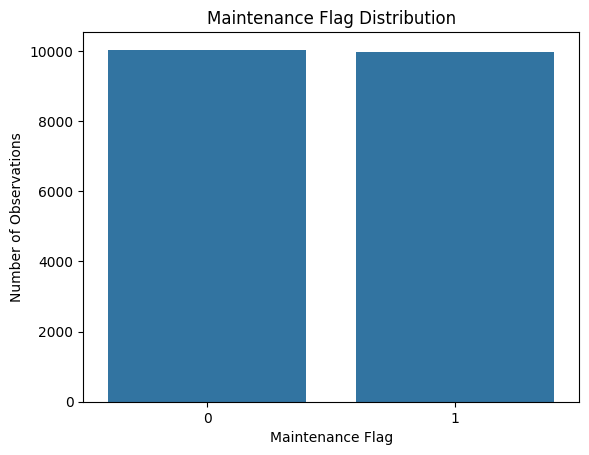

In [39]:
sns.countplot(data=df, x="Maintenance_Flag")
plt.title("Maintenance Flag Distribution")
plt.xlabel("Maintenance Flag")
plt.ylabel("Number of Observations")
plt.show()

The target variable, Maintenance_Flag, was approximately balanced, with 50.16% of observations belonging to class 0 and 49.84% belonging to class 1

Plot the feature distributions

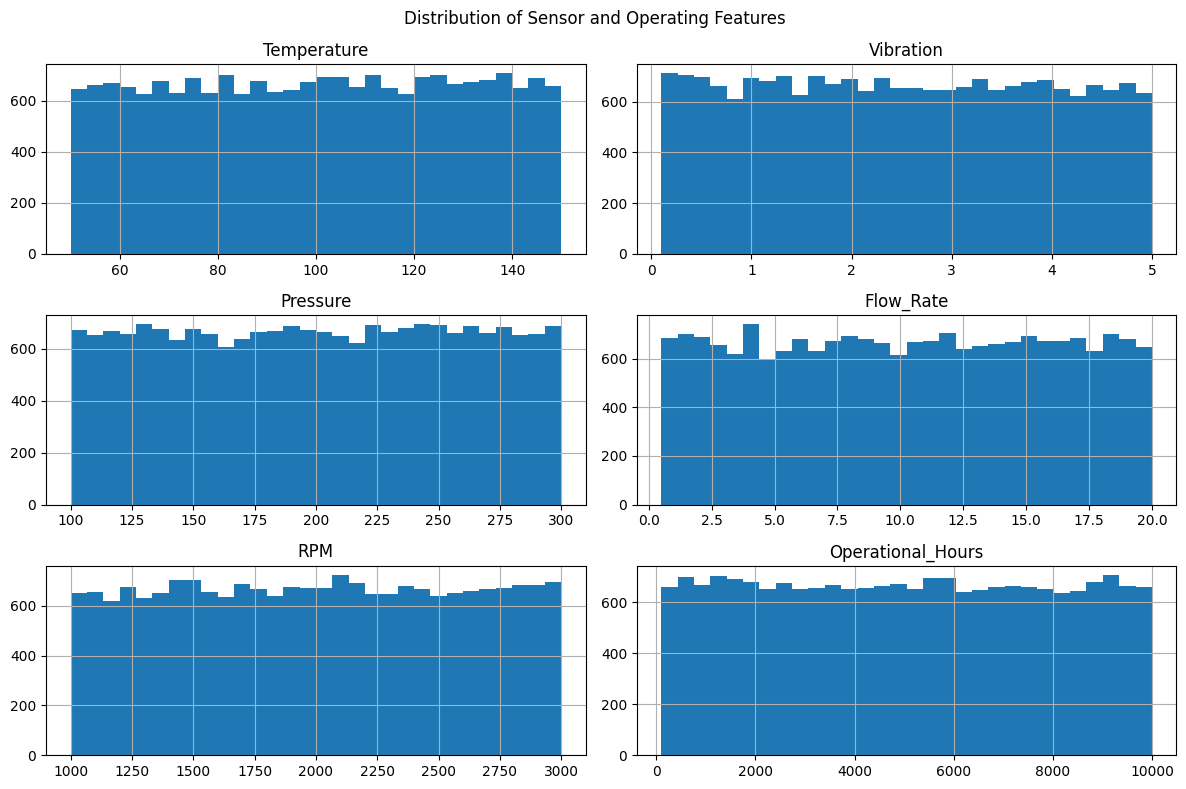

In [40]:
features = [
    "Temperature",
    "Vibration",
    "Pressure",
    "Flow_Rate",
    "RPM",
    "Operational_Hours"
]

df[features].hist(
    bins=30,
    figsize=(12, 8)
)

plt.suptitle("Distribution of Sensor and Operating Features")
plt.tight_layout()
plt.show()

In [41]:
df["Operational_Hours"].min(), df["Operational_Hours"].max()

(np.float64(100.2138802356134), np.float64(9998.768972009935))

In [42]:
df["Operational_Hours"].describe()

count    20000.000000
mean      5030.481037
std       2867.804461
min        100.213880
25%       2531.552283
50%       5032.760791
75%       7504.463849
max       9998.768972
Name: Operational_Hours, dtype: float64

compare features against the target

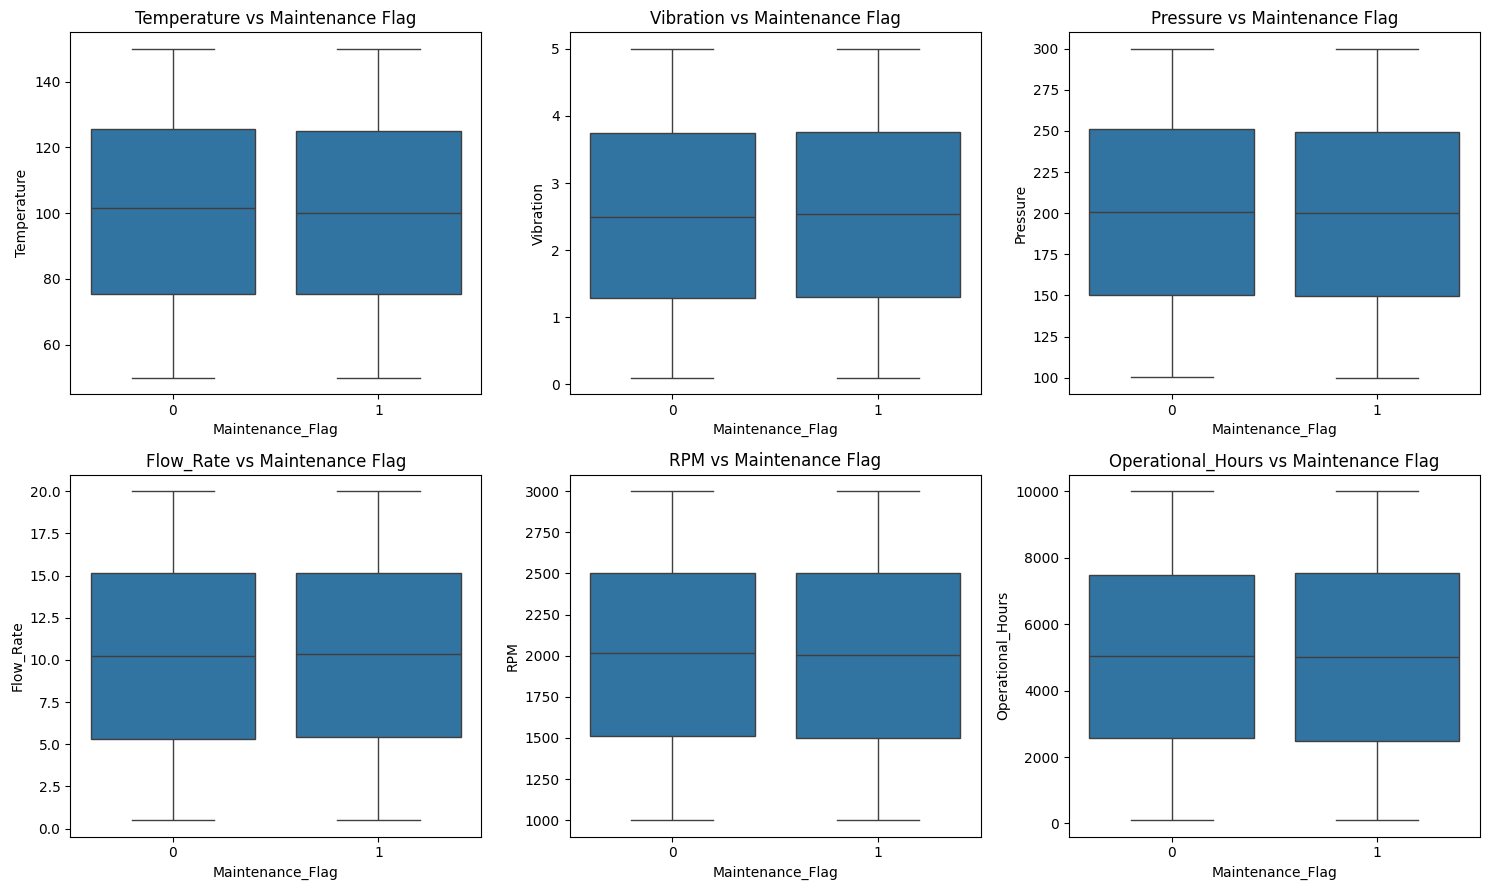

In [43]:
features = [
    "Temperature",
    "Vibration",
    "Pressure",
    "Flow_Rate",
    "RPM",
    "Operational_Hours"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="Maintenance_Flag", y=feature, ax=ax)
    ax.set_title(f"{feature} vs Maintenance Flag")

plt.tight_layout()
plt.show()

compare actual means between classes

In [44]:
df.groupby("Maintenance_Flag")[
    [
        "Temperature",
        "Vibration",
        "Pressure",
        "Flow_Rate",
        "RPM",
        "Operational_Hours"
    ]
].mean()

,Temperature,Vibration,Pressure,Flow_Rate,RPM,Operational_Hours
Maintenance_Flag,,,,,,
0,100.746785,2.517161,200.679232,10.199296,2010.538768,5039.337827
1,99.993484,2.538619,200.082087,10.297241,2000.664014,5021.567381


In [45]:
group_means = df.groupby("Maintenance_Flag")[
    [
        "Temperature",
        "Vibration",
        "Pressure",
        "Flow_Rate",
        "RPM",
        "Operational_Hours"
    ]
].mean()

group_means.loc[1] - group_means.loc[0]

Temperature          -0.753301
Vibration             0.021458
Pressure             -0.597145
Flow_Rate             0.097945
RPM                  -9.874755
Operational_Hours   -17.770446
dtype: float64

correlation analysis

In [46]:
correlation_matrix = df[
    [
        "Temperature",
        "Vibration",
        "Pressure",
        "Flow_Rate",
        "RPM",
        "Operational_Hours",
        "Maintenance_Flag"
    ]
].corr()

correlation_matrix

,Temperature,Vibration,Pressure,Flow_Rate,RPM,Operational_Hours,Maintenance_Flag
Temperature,1.000000,-0.003828,0.010348,-0.007030,-0.002716,-0.005662,-0.013055
Vibration,-0.003828,1.000000,-0.000670,-0.010816,0.014048,0.006401,0.007575
Pressure,0.010348,-0.000670,1.000000,0.011846,0.013011,0.004281,-0.005164
Flow_Rate,-0.007030,-0.010816,0.011846,1.000000,0.001757,-0.004263,0.008674
RPM,-0.002716,0.014048,0.013011,0.001757,1.000000,0.008139,-0.008564
Operational_Hours,-0.005662,0.006401,0.004281,-0.004263,0.008139,1.000000,-0.003098
Maintenance_Flag,-0.013055,0.007575,-0.005164,0.008674,-0.008564,-0.003098,1.000000


In [47]:
from sklearn.feature_selection import mutual_info_classif

features = [
    "Temperature",
    "Vibration",
    "Pressure",
    "Flow_Rate",
    "RPM",
    "Operational_Hours"
]

X = df[features]
y = df["Maintenance_Flag"]

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_results = pd.Series(
    mi_scores,
    index=features
).sort_values(ascending=False)

mi_results

Temperature          0.001380
Operational_Hours    0.000599
Pressure             0.000267
Vibration            0.000000
Flow_Rate            0.000000
RPM                  0.000000
dtype: float64

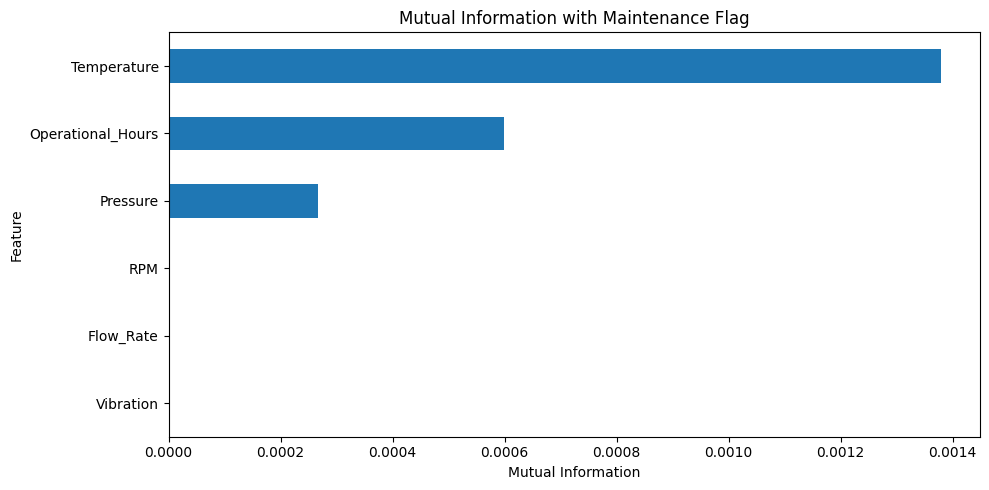

In [48]:
plt.figure(figsize=(10, 5))

mi_results.sort_values().plot(kind="barh")

plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Mutual Information with Maintenance Flag")
plt.tight_layout()
plt.show()

In [49]:
pump_maintenance = pd.crosstab(
    df["Pump_ID"],
    df["Maintenance_Flag"],
    normalize="index"
) * 100

pump_maintenance

Maintenance_Flag,0,1
Pump_ID,,
1,49.757095,50.242905
2,50.133204,49.866796
3,50.089036,49.910964
4,49.430129,50.569871
5,51.389932,48.610068


Create X and y

In [50]:
features = [
    "Temperature",
    "Vibration",
    "Pressure",
    "Flow_Rate",
    "RPM",
    "Operational_Hours"
]

X = df[features]
y = df["Maintenance_Flag"]

In [51]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 6)
y shape: (20000,)


Split the data

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [53]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16000
Testing samples: 4000


Model 1 — Logistic Regression

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

Train it

In [55]:
logistic_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [56]:
y_pred = logistic_model.predict(X_test)

In [57]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

Evaluate it

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

In [60]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.49525
Precision: 0.49304396215915414
Recall   : 0.44433299899699097
F1-score : 0.4674228435768926
ROC-AUC  : 0.5015757641818777


Confusion Matrix

In [61]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1095  911]
 [1108  886]]


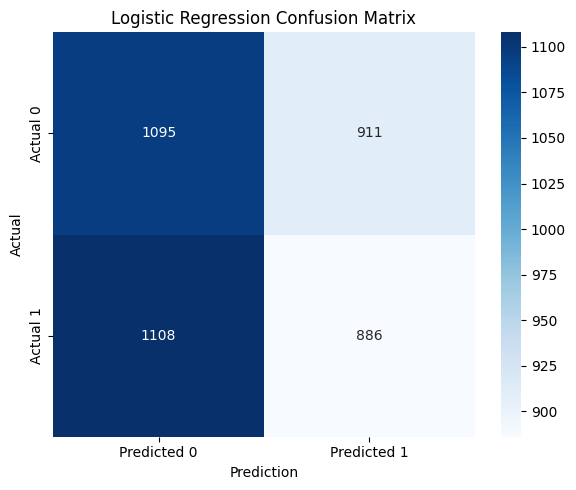

In [62]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

## Baseline Model: Logistic Regression

A Logistic Regression model was selected as the first baseline classifier.
The input features were standardized using StandardScaler within a
scikit-learn Pipeline to prevent data leakage during preprocessing.

The model was evaluated on a held-out 20% test set using Accuracy,
Precision, Recall, F1-score and ROC-AUC.

The model achieved an accuracy of approximately 49.5% and an ROC-AUC
of approximately 0.502, indicating near-random discrimination between
the two maintenance classes. This result is consistent with the EDA,
which showed substantial overlap between classes and very weak
feature-target correlations.

Model 2 — Decision Tree

In [63]:
from sklearn.tree import DecisionTreeClassifier

In [64]:
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [66]:
decision_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [67]:
y_pred_dt = decision_tree.predict(X_test)

y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

In [69]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree")
print("----------------------")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1-score :", f1_dt)
print("ROC-AUC  :", roc_auc_dt)

Decision Tree
----------------------
Accuracy : 0.496
Precision: 0.375
Recall   : 0.016549648946840523
F1-score : 0.03170028818443804
ROC-AUC  : 0.4895044055396498


In [70]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[1951   55]
 [1961   33]]


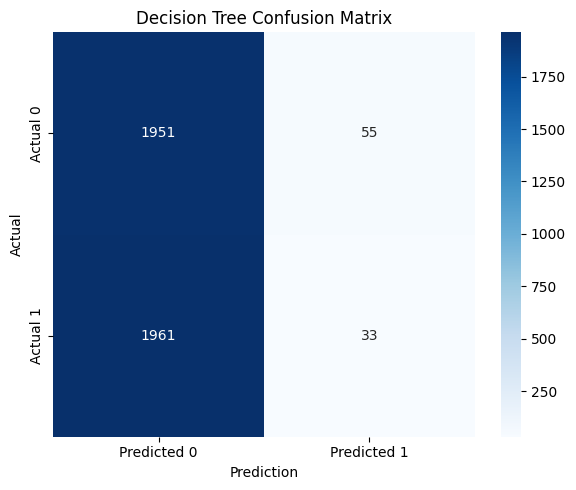

In [71]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

model 3: Dummy Classifier

In [72]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

In [73]:
dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
dummy_precision = precision_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)
dummy_recall = recall_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)
dummy_f1 = f1_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)

print("Dummy Classifier")
print("----------------------")
print("Accuracy :", dummy_accuracy)
print("Precision:", dummy_precision)
print("Recall   :", dummy_recall)
print("F1-score :", dummy_f1)

Dummy Classifier
----------------------
Accuracy : 0.5015
Precision: 0.0
Recall   : 0.0
F1-score : 0.0


In [74]:
dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
dummy_precision = precision_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)
dummy_recall = recall_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)
dummy_f1 = f1_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)

print("Dummy Classifier")
print("----------------------")
print("Accuracy :", dummy_accuracy)
print("Precision:", dummy_precision)
print("Recall   :", dummy_recall)
print("F1-score :", dummy_f1)

Dummy Classifier
----------------------
Accuracy : 0.5015
Precision: 0.0
Recall   : 0.0
F1-score : 0.0


In [76]:
feature_importance = pd.Series(
    decision_tree.feature_importances_,
    index=features
).sort_values(ascending=False)

feature_importance

Flow_Rate            0.324999
Temperature          0.245675
Vibration            0.182997
Operational_Hours    0.165916
Pressure             0.054701
RPM                  0.025712
dtype: float64

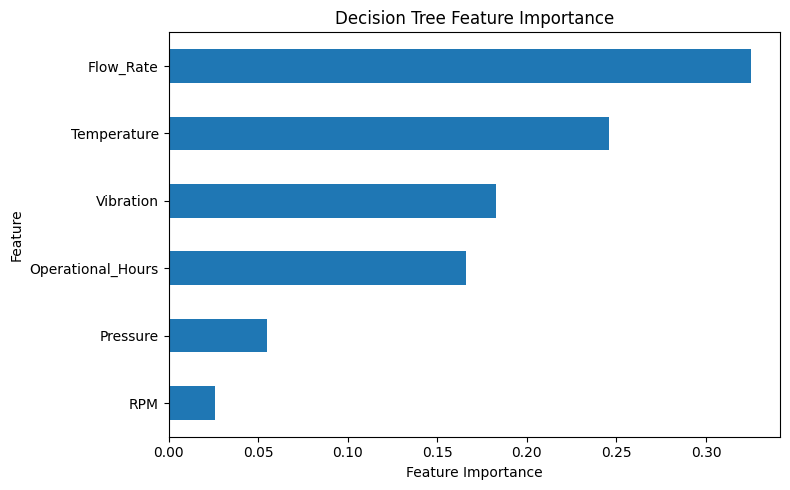

In [77]:
plt.figure(figsize=(8, 5))

feature_importance.sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

Tune the Decision Tree

In [78]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20]

tree_results = []

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    pred = tree.predict(X_test)
    prob = tree.predict_proba(X_test)[:, 1]

    tree_results.append({
        "max_depth": depth,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, prob)
    })

tree_results_df = pd.DataFrame(tree_results)

tree_results_df

,max_depth,accuracy,precision,recall,f1,roc_auc
0,1,0.49950,0.400000,0.008024,0.015733,0.498030
1,2,0.49950,0.400000,0.008024,0.015733,0.498026
2,3,0.49600,0.380435,0.017553,0.033557,0.494827
3,4,0.49625,0.382022,0.017051,0.032645,0.493607
4,5,0.49600,0.375000,0.016550,0.031700,0.489504
5,6,0.49600,0.385417,0.018556,0.035407,0.490283
6,8,0.50450,0.502846,0.531595,0.516821,0.499042
7,10,0.50425,0.503607,0.385155,0.436488,0.497653
8,15,0.50125,0.499684,0.396189,0.441958,0.503875
9,20,0.49975,0.498421,0.554162,0.524816,0.513047


proper cross-validation

In [79]:
from sklearn.model_selection import cross_val_score

depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20]

cv_results = []

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(
        tree,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    cv_results.append({
        "max_depth": depth,
        "mean_roc_auc": scores.mean(),
        "std_roc_auc": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,max_depth,mean_roc_auc,std_roc_auc
0,1,0.498102,0.004441
1,2,0.497201,0.004519
2,3,0.496726,0.004252
3,4,0.499153,0.007627
4,5,0.501071,0.007323
5,6,0.500848,0.010428
6,8,0.503546,0.008229
7,10,0.500428,0.008188
8,15,0.501437,0.007259
9,20,0.510489,0.009622


train the selected tree

Based on the CV results, depth 20 has the highest mean ROC-AUC.

In [80]:
final_tree = DecisionTreeClassifier(
    max_depth=20,
    random_state=42
)

final_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [81]:
final_tree_pred = final_tree.predict(X_test)
final_tree_prob = final_tree.predict_proba(X_test)[:, 1]

In [82]:
final_tree_accuracy = accuracy_score(
    y_test,
    final_tree_pred
)

final_tree_precision = precision_score(
    y_test,
    final_tree_pred,
    zero_division=0
)

final_tree_recall = recall_score(
    y_test,
    final_tree_pred,
    zero_division=0
)

final_tree_f1 = f1_score(
    y_test,
    final_tree_pred,
    zero_division=0
)

final_tree_auc = roc_auc_score(
    y_test,
    final_tree_prob
)

print("Final Decision Tree (max_depth=20)")
print("--------------------------------")
print("Accuracy :", final_tree_accuracy)
print("Precision:", final_tree_precision)
print("Recall   :", final_tree_recall)
print("F1-score :", final_tree_f1)
print("ROC-AUC  :", final_tree_auc)

Final Decision Tree (max_depth=20)
--------------------------------
Accuracy : 0.49975
Precision: 0.4984212900315742
Recall   : 0.5541624874623872
F1-score : 0.524815958204702
ROC-AUC  : 0.5130469924229318


In [83]:
final_cm = confusion_matrix(y_test, final_tree_pred)

print(final_cm)

[[ 894 1112]
 [ 889 1105]]


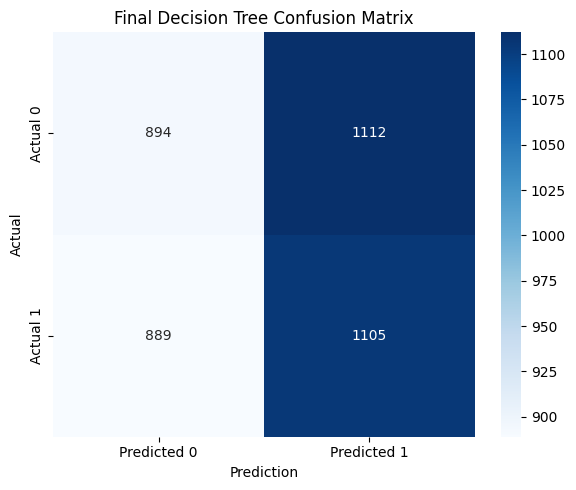

In [84]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Final Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

ROC Curve

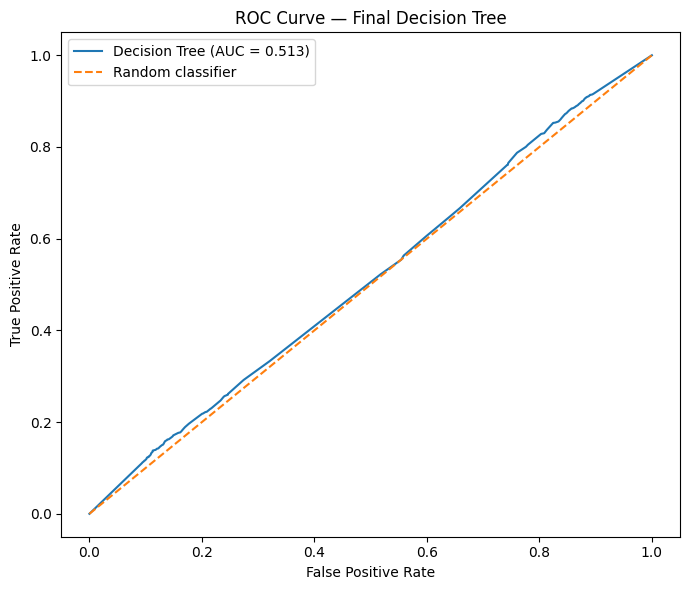

In [85]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    final_tree_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Decision Tree (AUC = {final_tree_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

The ROC curve of the tuned Decision Tree remained close to the random-classifier diagonal, with an ROC-AUC of 0.513. This indicates that the model has limited ability to distinguish between the two maintenance classes based on the available sensor and operational features.

Model 3 — KNN(K-Nearest Neighbors)

In [86]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [87]:
k_values = [3, 5, 7, 9, 11, 15, 21, 31]

knn_cv_results = []

for k in k_values:

    knn_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        knn_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    knn_cv_results.append({
        "k": k,
        "mean_roc_auc": scores.mean(),
        "std_roc_auc": scores.std()
    })

knn_cv_results_df = pd.DataFrame(knn_cv_results)

knn_cv_results_df

,k,mean_roc_auc,std_roc_auc
0,3,0.497938,0.004476
1,5,0.496431,0.012299
2,7,0.500940,0.008428
3,9,0.499280,0.010168
4,11,0.500203,0.010317
5,15,0.493148,0.006101
6,21,0.493526,0.008529
7,31,0.493069,0.005191


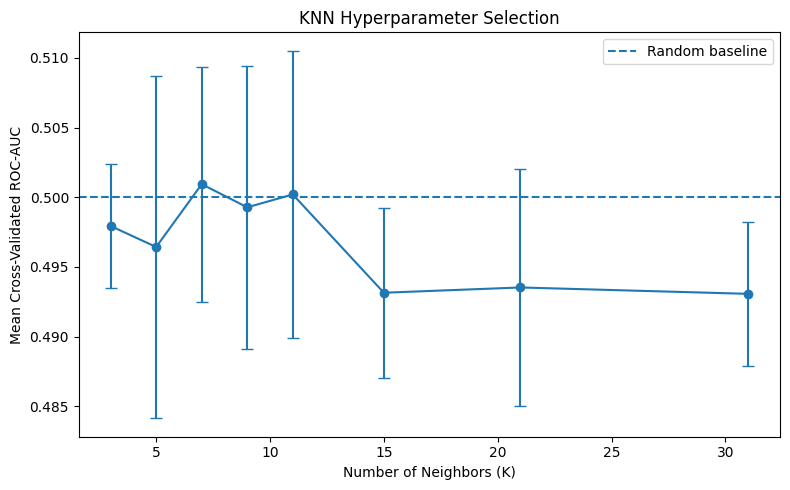

In [88]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    knn_cv_results_df["k"],
    knn_cv_results_df["mean_roc_auc"],
    yerr=knn_cv_results_df["std_roc_auc"],
    marker="o",
    capsize=4
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Cross-Validated ROC-AUC")
plt.title("KNN Hyperparameter Selection")
plt.legend()
plt.tight_layout()
plt.show()

In [89]:
final_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=7))
])

final_knn.fit(X_train, y_train)

,steps,"[('scaler', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [90]:
final_knn_pred = final_knn.predict(X_test)
final_knn_prob = final_knn.predict_proba(X_test)[:, 1]

In [91]:
final_knn_accuracy = accuracy_score(
    y_test,
    final_knn_pred
)

final_knn_precision = precision_score(
    y_test,
    final_knn_pred,
    zero_division=0
)

final_knn_recall = recall_score(
    y_test,
    final_knn_pred,
    zero_division=0
)

final_knn_f1 = f1_score(
    y_test,
    final_knn_pred,
    zero_division=0
)

final_knn_auc = roc_auc_score(
    y_test,
    final_knn_prob
)

print("Final KNN (K=7)")
print("----------------")
print("Accuracy :", final_knn_accuracy)
print("Precision:", final_knn_precision)
print("Recall   :", final_knn_recall)
print("F1-score :", final_knn_f1)
print("ROC-AUC  :", final_knn_auc)

Final KNN (K=7)
----------------
Accuracy : 0.5005
Precision: 0.499000999000999
Recall   : 0.5010030090270813
F1-score : 0.5
ROC-AUC  : 0.48745538709848385


In [93]:
knn_cm = confusion_matrix(
    y_test,
    final_knn_pred
)

print(knn_cm)

[[1003 1003]
 [ 995  999]]


In [94]:
for feature in features:
    print(f"\n===== {feature} =====")
    print(
        df.groupby("Maintenance_Flag")[feature]
        .agg(["mean", "std", "min", "max"])
    )


===== Temperature =====
                        mean        std        min         max
Maintenance_Flag                                              
0                 100.746785  28.844335  50.003401  149.992791
1                  99.993484  28.854983  50.001091  149.995262

===== Vibration =====
                      mean       std       min       max
Maintenance_Flag                                        
0                 2.517161  1.416975  0.100427  4.999135
1                 2.538619  1.415942  0.101268  4.999804

===== Pressure =====
                        mean        std         min         max
Maintenance_Flag                                               
0                 200.679232  57.757669  100.099058  299.980845
1                 200.082087  57.890198  100.007052  299.973381

===== Flow_Rate =====
                       mean       std       min        max
Maintenance_Flag                                          
0                 10.199296  5.653666  0.500636  19.9

In [95]:
import pandas as pd

features = [
    "Temperature",
    "Vibration",
    "Pressure",
    "Flow_Rate",
    "RPM",
    "Operational_Hours"
]

outlier_results = []

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    outlier_results.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": len(outliers) / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_results)

outlier_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Temperature,75.403208,125.422558,50.019350,0.374183,200.451583,0,0.0
1,Vibration,1.300199,3.755519,2.455321,-2.382782,7.438500,0,0.0
2,Pressure,149.858536,250.271651,100.413115,-0.761136,400.891323,0,0.0
3,Flow_Rate,5.354906,15.149339,9.794433,-9.336743,29.840988,0,0.0
4,RPM,1506.073027,2503.339719,997.266691,10.172990,3999.239756,0,0.0
5,Operational_Hours,2531.552283,7504.463849,4972.911567,-4927.815068,14963.831200,0,0.0


Data Leakage Check

In [96]:
features = [
    "Temperature",
    "Vibration",
    "Pressure",
    "Flow_Rate",
    "RPM",
    "Operational_Hours"
]

X = df[features]
y = df["Maintenance_Flag"]

In [97]:
print("Features used for prediction:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nTarget included in features?")
print("Maintenance_Flag" in X.columns)

print("\nPump_ID included in features?")
print("Pump_ID" in X.columns)

Features used for prediction:
['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM', 'Operational_Hours']

Target:
Maintenance_Flag

Target included in features?
False

Pump_ID included in features?
False


Data leakage check: The target variable, Maintenance_Flag, was separated from the predictor variables before model training. Pump_ID was excluded because it is an identifier rather than a predictive sensor/operational measurement. The final feature set consisted of Temperature, Vibration, Pressure, Flow_Rate, RPM, and Operational_Hours.

Error Analysis

In [98]:
final_tree_accuracy = accuracy_score(
    y_test,
    final_tree_pred
)

final_tree_precision = precision_score(
    y_test,
    final_tree_pred,
    zero_division=0
)

final_tree_recall = recall_score(
    y_test,
    final_tree_pred,
    zero_division=0
)

final_tree_f1 = f1_score(
    y_test,
    final_tree_pred,
    zero_division=0
)

final_tree_auc = roc_auc_score(
    y_test,
    final_tree_prob
)

print("Final Decision Tree (max_depth=20)")
print("--------------------------------")
print("Accuracy :", final_tree_accuracy)
print("Precision:", final_tree_precision)
print("Recall   :", final_tree_recall)
print("F1-score :", final_tree_f1)
print("ROC-AUC  :", final_tree_auc)

Final Decision Tree (max_depth=20)
--------------------------------
Accuracy : 0.49975
Precision: 0.4984212900315742
Recall   : 0.5541624874623872
F1-score : 0.524815958204702
ROC-AUC  : 0.5130469924229318


In [99]:
final_tree_accuracy = accuracy_score(
    y_test,
    final_tree_pred
)

final_tree_precision = precision_score(
    y_test,
    final_tree_pred,
    zero_division=0
)

final_tree_recall = recall_score(
    y_test,
    final_tree_pred,
    zero_division=0
)

final_tree_f1 = f1_score(
    y_test,
    final_tree_pred,
    zero_division=0
)

final_tree_auc = roc_auc_score(
    y_test,
    final_tree_prob
)

print("Final Decision Tree (max_depth=20)")
print("--------------------------------")
print("Accuracy :", final_tree_accuracy)
print("Precision:", final_tree_precision)
print("Recall   :", final_tree_recall)
print("F1-score :", final_tree_f1)
print("ROC-AUC  :", final_tree_auc)

Final Decision Tree (max_depth=20)
--------------------------------
Accuracy : 0.49975
Precision: 0.4984212900315742
Recall   : 0.5541624874623872
F1-score : 0.524815958204702
ROC-AUC  : 0.5130469924229318


In [100]:
y_pred = final_tree.predict(X_test)

error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_pred

false_positives = error_analysis[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
]

false_negatives = error_analysis[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

print("\nFalse Positive feature means:")
print(false_positives[features].mean())

print("\nFalse Negative feature means:")
print(false_negatives[features].mean())

False Positives: 1112
False Negatives: 889

False Positive feature means:
Temperature           102.959033
Vibration               2.480504
Pressure              198.854568
Flow_Rate               9.996568
RPM                  1900.986392
Operational_Hours    4940.923035
dtype: float64

False Negative feature means:
Temperature            98.227406
Vibration               2.657881
Pressure              201.175002
Flow_Rate              10.692015
RPM                  2153.716826
Operational_Hours    5149.321968
dtype: float64


Error analysis showed substantial misclassification, with 1,112 false positives and 889 false negatives on the test set. The feature means of the two error groups showed some differences, particularly in RPM and operational hours; however, these differences

In [101]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(final_tree, "models/decision_tree_model.pkl")
joblib.dump(features, "models/feature_names.pkl")

print("Model saved successfully.")

Model saved successfully.
